In [1]:
using CMPSKit, Plots, OptimKit, KrylovKit, LinearAlgebra, LaTeXStrings

In [ ]:
# Local densities:
n̂ = ψ̂' * ψ̂; # particle density operator
k̂ = ∂ψ̂' * ∂ψ̂; # kinetic energy density operator
û = (ψ̂')^2 * ψ̂^2; # interaction operator
p̂ = ψ̂' * ψ̂' + ψ̂ * ψ̂;

H(; c, μ, Δ) = ∫(k̂ - μ * n̂ + c * û + Δ * p̂, (-Inf, +Inf));

find_groundstate (generic function with 1 method)

In [12]:
#c, μ, Δ = 1.0, 0.5, -0.3
c, μ, Δ = 10.0, 5.0, -1.

tol = 1.0e-10
hamiltonian = H(c = c, μ = μ, Δ = Δ)
hamiltonian_density = hamiltonian.h

Ds = [8]
state = find_groundstate(Ds, hamiltonian, optalg = LBFGS(80; verbosity = 1, maxiter = 7000, gradtol = tol), gradtol = tol)
D = maximum(Ds)

println("Energy density: ", expval(hamiltonian_density, state)[], "\n Particle density: ", expval(n̂, state)[], "\n Order parameter: ", expval(ψ̂, state)[])

Optimizing D=8


┌ Info: UniformCMPS ground state: initialization with e = 64.081036047603
└ @ CMPSKit c:\Users\saksh\Documents\PhDstuff\code\TensorNetworks\CMPSKit.jl\src\infinitecmps\groundstate.jl:115


  4.490213 seconds (2.66 M allocations: 294.157 MiB, 0.98% gc time)
---------------
Energy density: -3.021392430591679
 Particle density: 0.9040484447461766
 Order parameter: 0.7574905073891988


┌ Info: UniformCMPS ground state: converged after 259 iterations: e = -3.021392430592, ‖∇e‖ = 6.4980e-11
└ @ CMPSKit c:\Users\saksh\Documents\PhDstuff\code\TensorNetworks\CMPSKit.jl\src\infinitecmps\groundstate.jl:127


In [13]:
nvals = 10

ρ = expval(n̂, state)[]
ps = range(-2π * ρ, 2π * ρ, 40)
trivial_spectrum = zeros(ComplexF64, length(ps), nvals);

Threads.@threads for idx in eachindex(ps)
    space = InfiniteCMPSExcitationSpace(ps[idx], state, state)
    Heff = excitation_operator(hamiltonian, space)
    trivial_spectrum[idx, :] .= eigsolve(Heff, (Constant(rand(ComplexF64, size(state.Q[]))),), nvals, :SR)[1][1:nvals]
end

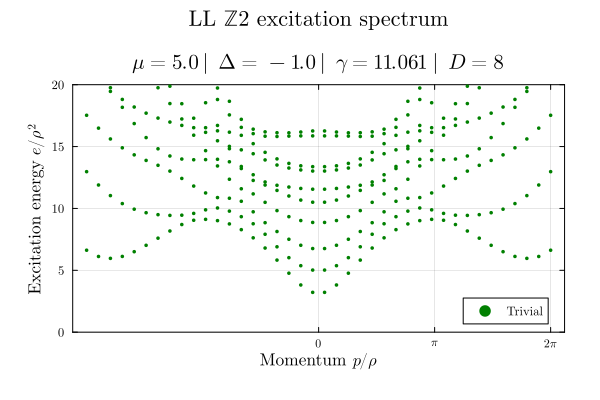

In [14]:
scatter(ps ./ ρ, real.(trivial_spectrum) ./ ρ^2, ylims = [0, 20], lab = permutedims(["Trivial"; fill("", nvals - 1)]), ms = 2, c = :green, markerstrokewidth = 0)
plot!(xtick = pitick(0, 4π, 1, mode = :latex), ylabel = "Excitation energy " * L"e/\rho^2", xlabel = "Momentum " * L"p/\rho", title = "LL ℤ2 excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ Δ=%$(Δ) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins = 7Plots.mm)

In [7]:
nvals = 15
pts = range(-2π * ρ, 2π * ρ, 40)
topological_spectrum = zeros(ComplexF64, length(pts), nvals);
topological_excitations = [[zeros(ComplexF64, size(state.Q[])) for _ in 1:nvals] for _ in eachindex(pts)]

theta = π
state = InfiniteCMPS(Constant(ComplexF64.(state.Q[])), Constant(ComplexF64.(state.Rs[1][])))
state_alt = InfiniteCMPS(state.Q, exp(1im * theta) * state.Rs[1])

Threads.@threads for idx in eachindex(pts)
    space = InfiniteCMPSExcitationSpace(pts[idx], state, state_alt)
    Heff = excitation_operator(hamiltonian, space)
    vals, vecs, _ = eigsolve(Heff, (Constant(rand(ComplexF64, size(state.Q[]))),), nvals, :SR)
    topological_spectrum[idx, :] .= vals[1:nvals]
    topological_excitations[idx] .= getindex.(getindex.(vecs[1:nvals], 1))
end


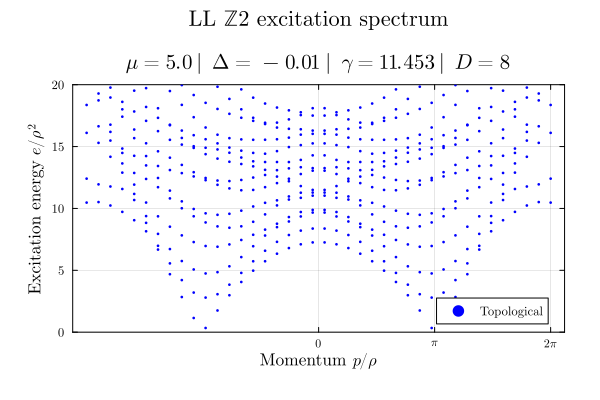

In [8]:
scatter(pts ./ ρ, real.(topological_spectrum) ./ ρ^2, ylims = [0, 20], lab = permutedims(["Topological"; fill("", nvals - 1)]), ms = 1.5, c = :blue, markerstrokewidth = 0)
plot!(xtick = pitick(0, 4π, 1, mode = :latex), ylabel = "Excitation energy " * L"e/\rho^2", xlabel = "Momentum " * L"p/\rho", title = "LL ℤ2 excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ Δ=%$(Δ) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins = 7Plots.mm)


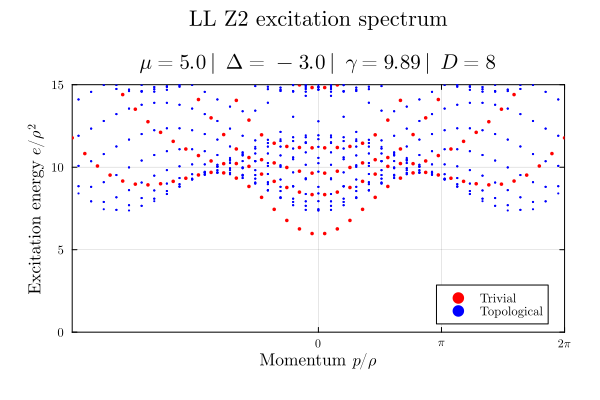

In [9]:
topo_exc = collect(Iterators.flatten(zip.(Ref(pts), eachcol(real.(topological_spectrum)))))
topo_combinations = collect(zip(vec(first.(topo_exc) .+ first.(topo_exc)'), vec(last.(topo_exc) .+ last.(topo_exc)')))

scatter(ps ./ ρ, real.(trivial_spectrum) ./ ρ^2, lab = permutedims(["Trivial"; fill("", nvals - 1)]), ms = 2, c = :red, markerstrokewidth = 0)
scatter!(first.(topo_combinations) ./ ρ, last.(topo_combinations) ./ ρ^2, lab = permutedims(["Topological"; fill("", nvals - 1)]), ms = 1.2, c = :blue, markerstrokewidth = 0)
plot!(xtick = pitick(0, 4π, 1, mode = :latex), ylabel = "Excitation energy " * L"e/\rho^2", xlabel = "Momentum " * L"p/\rho", title = "LL Z2 excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ Δ=%$(Δ) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins = 7Plots.mm, ylims = [0, 15], xlims = [-2π, 2π])
